# 2D Frequency Domain Filtering (FFT, Ideal, Gaussian & Butterworth Filters)

### Mathematical Foundations of Frequency Domain Processing:

#### 1. 2D Discrete Fourier Transform (DFT) & Inverse DFT (IDFT):

For an $M \times N$ discrete image $f(x, y)$:

- **Forward 2D DFT:**
  $$F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x, y) \cdot e^{-j 2\pi \left(\frac{ux}{M} + \frac{vy}{N}\right)}$$
- **Inverse 2D DFT (IDFT):**
  $$f(x, y) = \frac{1}{M N} \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} F(u, v) \cdot e^{j 2\pi \left(\frac{ux}{M} + \frac{vy}{N}\right)}$$

#### 2. Centered Frequency Spectrum & Log Magnitude:

Zero-frequency (DC component $F(0, 0) = \sum f(x, y)$) is shifted to the spectrum center $(u_0, v_0) = (M/2, N/2)$ via `np.fft.fftshift`.

- **Radial Frequency Distance Metric:**
  $$D(u, v) = \sqrt{(u - M/2)^2 + (v - N/2)^2}$$
- **Logarithmic Magnitude Spectrum:**
  $$S(u, v) = 20 \log_{10}(1 + |F_{\text{shift}}(u, v)|)$$

#### 3. Low-Pass Filter (LPF) Transfer Functions $H(u, v)$:

- **Ideal Low-Pass Filter (ILPF):**
  $$H_{\text{ILPF}}(u, v) = \begin{cases} 1 & \text{if } D(u, v) \le D_0 \\ 0 & \text{if } D(u, v) > D_0 \end{cases}$$
  _(Discontinuous step edge in frequency produces concentric **ringing / Gibbs ripple artifacts** in spatial domain)._
- **Gaussian Low-Pass Filter (GLPF):**
  $$H_{\text{GLPF}}(u, v) = e^{-\frac{D^2(u, v)}{2 D_0^2}}$$
  _(Completely smooth Gaussian bell curve; Fourier transform of a Gaussian is another Gaussian; **strictly zero ringing**)._
- **Butterworth Low-Pass Filter (BLPF) of order $n$:**
  $$H_{\text{BLPF}}(u, v) = \frac{1}{1 + \left(\frac{D(u, v)}{D_0}\right)^{2n}}$$
  _(Smooth transitional roll-off controlled by order $n$; balances sharp cutoff with minimal ringing)._

#### 4. High-Pass Filter (HPF) Transfer Functions:

By complementary property: $H_{\text{HP}}(u, v) = 1 - H_{\text{LP}}(u, v)$

- **Ideal High-Pass Filter (IHPF):**
  $$H_{\text{IHPF}}(u, v) = \begin{cases} 0 & \text{if } D(u, v) \le D_0 \\ 1 & \text{if } D(u, v) > D_0 \end{cases}$$
- **Gaussian High-Pass Filter (GHPF):**
  $$H_{\text{GHPF}}(u, v) = 1 - e^{-\frac{D^2(u, v)}{2 D_0^2}}$$
- **Butterworth High-Pass Filter (BHPF):**
  $$H_{\text{BHPF}}(u, v) = \frac{1}{1 + \left(\frac{D_0}{D(u, v)}\right)^{2n}}$$

#### 5. Frequency Filtering Pipeline (Convolution Theorem):

$$g(x, y) = \text{Re}\Big( \text{IDFT}\big( \text{ifftshift}( F_{\text{shift}}(u, v) \cdot H(u, v) ) \big) \Big)$$

---

This notebook:

1. Loads an 8-bit grayscale image and computes its 2D Fast Fourier Transform (FFT) and centered logarithmic magnitude spectrum.
2. Implements Ideal (ILPF/IHPF), Gaussian (GLPF/GHPF), and Butterworth (BLPF/BHPF) frequency domain filters from scratch.
3. Evaluates low-pass and high-pass filtering across varying cutoff frequencies ($D_0 \in \{20, 50, 100\}$) and Butterworth filter orders ($n \in \{1, 2, 4, 8, 20\}$).
4. Displays comparative visualizations illustrating Gibbs ringing phenomena, smooth Gaussian denoising, and high-frequency edge isolation.
5. Quantitatively benchmarks frequency filtering across multiple test images and provides an in-depth analytical discussion.


In [ ]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Configure matplotlib rendering settings
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

## (i) Load Grayscale Image & Compute 2D Fourier Spectrum


             2D FOURIER SPECTRUM PROPERTIES
Image Dimensions (M x N)     : 640 x 612 pixels
DC Component Value F(0, 0)   : 27368197.00 (Total Image Sum: 27,368,197)
Spectrum Dynamic Range (dB)  : [25.89, 148.74]
IDFT Reconstruction MSE      : 1.0643949421e-27 (Exact Invertibility)


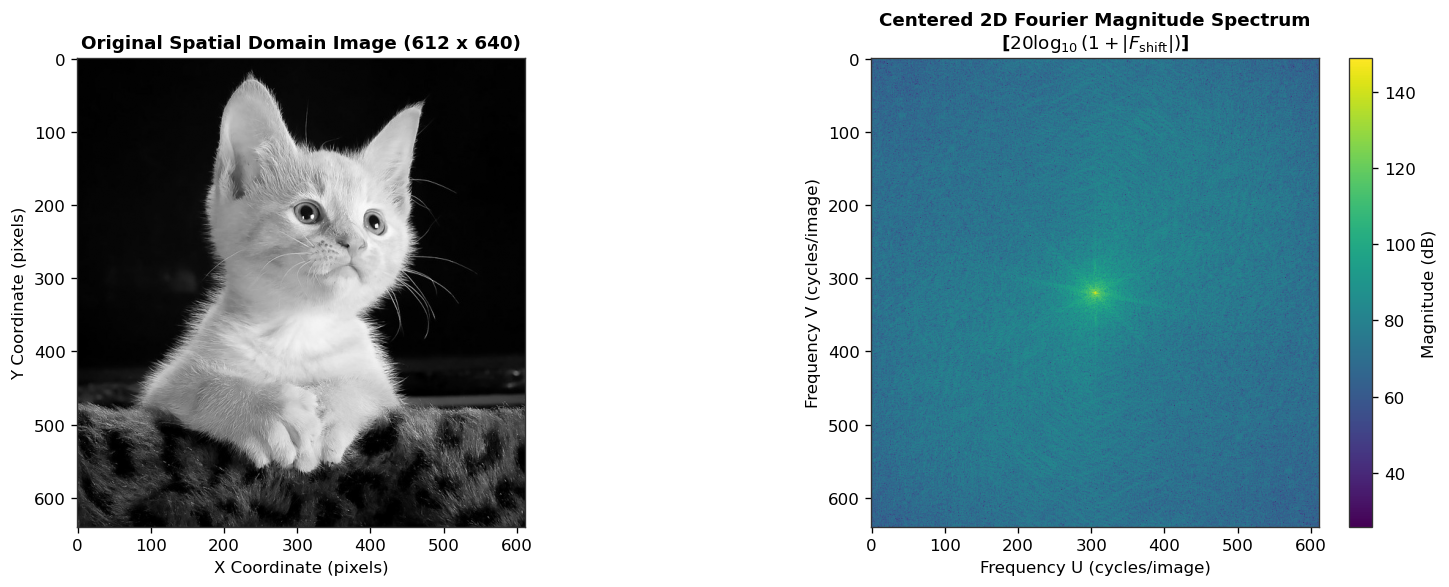

In [ ]:
def load_grayscale_image(path: str = "images/image1.jpg") -> np.ndarray:
    """
    Load an 8-bit grayscale image.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Image not found at: {path}")
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image at: {path}")
    return img


def compute_2d_fft(img: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute the 2D FFT, centered frequency spectrum, and logarithmic magnitude spectrum.
    """
    # 1. 2D Fast Fourier Transform
    f = np.fft.fft2(img.astype(np.float64))

    # 2. Shift zero-frequency DC component to center of spectrum
    f_shift = np.fft.fftshift(f)

    # 3. Logarithmic dynamic range compression for visual display
    mag_spectrum = 20.0 * np.log10(1.0 + np.abs(f_shift))

    return f, f_shift, mag_spectrum


img_original = load_grayscale_image("images/image1.jpg")
h, w = img_original.shape
f, f_shift, mag_spectrum = compute_2d_fft(img_original)

# Verify Perfect Invertibility (IDFT)
img_reconstructed = np.real(np.fft.ifft2(f))
reconstruction_mse = float(
    np.mean((img_original.astype(float) - img_reconstructed) ** 2)
)

print("=" * 60)
print("             2D FOURIER SPECTRUM PROPERTIES")
print("=" * 60)
print(f"Image Dimensions (M x N)     : {h} x {w} pixels")
print(
    f"DC Component Value F(0, 0)   : {np.abs(f[0, 0]):.2f} (Total Image Sum: {img_original.sum():,})"
)
print(
    f"Spectrum Dynamic Range (dB)  : [{mag_spectrum.min():.2f}, {mag_spectrum.max():.2f}]"
)
print(f"IDFT Reconstruction MSE      : {reconstruction_mse:.10e} (Exact Invertibility)")
print("=" * 60)

# Display Original Image & Centered Log Magnitude Spectrum
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(img_original, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(
    f"Original Spatial Domain Image ({w} x {h})", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("X Coordinate (pixels)")
axes[0].set_ylabel("Y Coordinate (pixels)")

im1 = axes[1].imshow(mag_spectrum, cmap="viridis")
axes[1].set_title(
    "Centered 2D Fourier Magnitude Spectrum\n[$20 \\log_{10}(1 + |F_{\\text{shift}}|)$]",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_xlabel("Frequency U (cycles/image)")
axes[1].set_ylabel("Frequency V (cycles/image)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Magnitude (dB)")

plt.tight_layout()
plt.show()

## (ii) Frequency Domain Filter Transfer Functions (ILPF, GLPF, BLPF & High-Pass Counterparts)


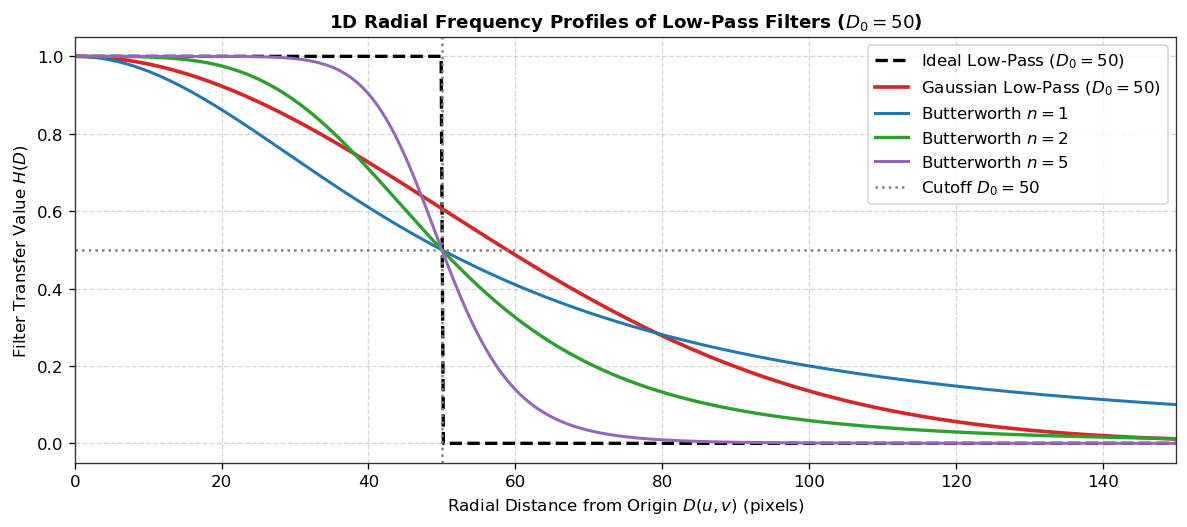

In [ ]:
def get_frequency_grid(
    shape: tuple[int, int],
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute the 2D Euclidean frequency distance matrix D(u, v) from spectrum center.
    """
    rows, cols = shape
    crow, ccol = rows / 2.0, cols / 2.0
    u, v = np.indices((rows, cols), dtype=np.float64)
    D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
    return u, v, D


def create_ideal_filter(
    shape: tuple[int, int], D0: float, filter_type: str = "low"
) -> np.ndarray:
    """Ideal Low-Pass / High-Pass Filter."""
    _, _, D = get_frequency_grid(shape)
    H_low = (D <= D0).astype(np.float64)
    return H_low if filter_type == "low" else (1.0 - H_low)


def create_gaussian_filter(
    shape: tuple[int, int], D0: float, filter_type: str = "low"
) -> np.ndarray:
    """Gaussian Low-Pass / High-Pass Filter."""
    _, _, D = get_frequency_grid(shape)
    H_low = np.exp(-(D**2) / (2.0 * (D0**2)))
    return H_low if filter_type == "low" else (1.0 - H_low)


def create_butterworth_filter(
    shape: tuple[int, int], D0: float, n: int = 2, filter_type: str = "low"
) -> np.ndarray:
    """Butterworth Low-Pass / High-Pass Filter of order n."""
    _, _, D = get_frequency_grid(shape)
    # Safe division avoiding divide-by-zero at center for high-pass
    if filter_type == "low":
        H = 1.0 / (1.0 + (D / D0) ** (2 * n))
    else:
        D_safe = np.where(D == 0, 1e-8, D)
        H = 1.0 / (1.0 + (D0 / D_safe) ** (2 * n))
        H[D == 0] = 0.0
    return H


def apply_frequency_filter(f_shift: np.ndarray, H: np.ndarray) -> np.ndarray:
    """
    Multiply shifted spectrum with filter transfer function and compute inverse FFT.
    """
    G_shift = f_shift * H
    g = np.fft.ifft2(np.fft.ifftshift(G_shift))
    return np.clip(np.real(g), 0, 255).astype(np.uint8)


# Plot 1D Radial Filter Response Comparison
D_vals = np.linspace(0, 150, 500)
D0_test = 50.0

H_ideal_1d = (D_vals <= D0_test).astype(float)
H_gauss_1d = np.exp(-(D_vals**2) / (2.0 * D0_test**2))
H_bw1_1d = 1.0 / (1.0 + (D_vals / D0_test) ** (2 * 1))
H_bw2_1d = 1.0 / (1.0 + (D_vals / D0_test) ** (2 * 2))
H_bw5_1d = 1.0 / (1.0 + (D_vals / D0_test) ** (2 * 5))

plt.figure(figsize=(10, 4.5))
plt.plot(
    D_vals,
    H_ideal_1d,
    label="Ideal Low-Pass ($D_0=50$)",
    color="black",
    linewidth=2,
    linestyle="--",
)
plt.plot(
    D_vals,
    H_gauss_1d,
    label="Gaussian Low-Pass ($D_0=50$)",
    color="#d62728",
    linewidth=2.2,
)
plt.plot(D_vals, H_bw1_1d, label="Butterworth $n=1$", color="#1f77b4", linewidth=1.8)
plt.plot(D_vals, H_bw2_1d, label="Butterworth $n=2$", color="#2ca02c", linewidth=2.0)
plt.plot(D_vals, H_bw5_1d, label="Butterworth $n=5$", color="#9467bd", linewidth=1.8)

plt.axvline(D0_test, color="gray", linestyle=":", label=f"Cutoff $D_0={int(D0_test)}$")
plt.axhline(0.5, color="gray", linestyle=":")
plt.title(
    "1D Radial Frequency Profiles of Low-Pass Filters ($D_0 = 50$)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Radial Distance from Origin $D(u, v)$ (pixels)", fontsize=10)
plt.ylabel("Filter Transfer Value $H(D)$", fontsize=10)
plt.xlim([0, 150])
plt.ylim([-0.05, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

## (iii) Low-Pass Filtering: Comparison of Cutoff Frequencies ($D_0 = 20, 50, 100$)


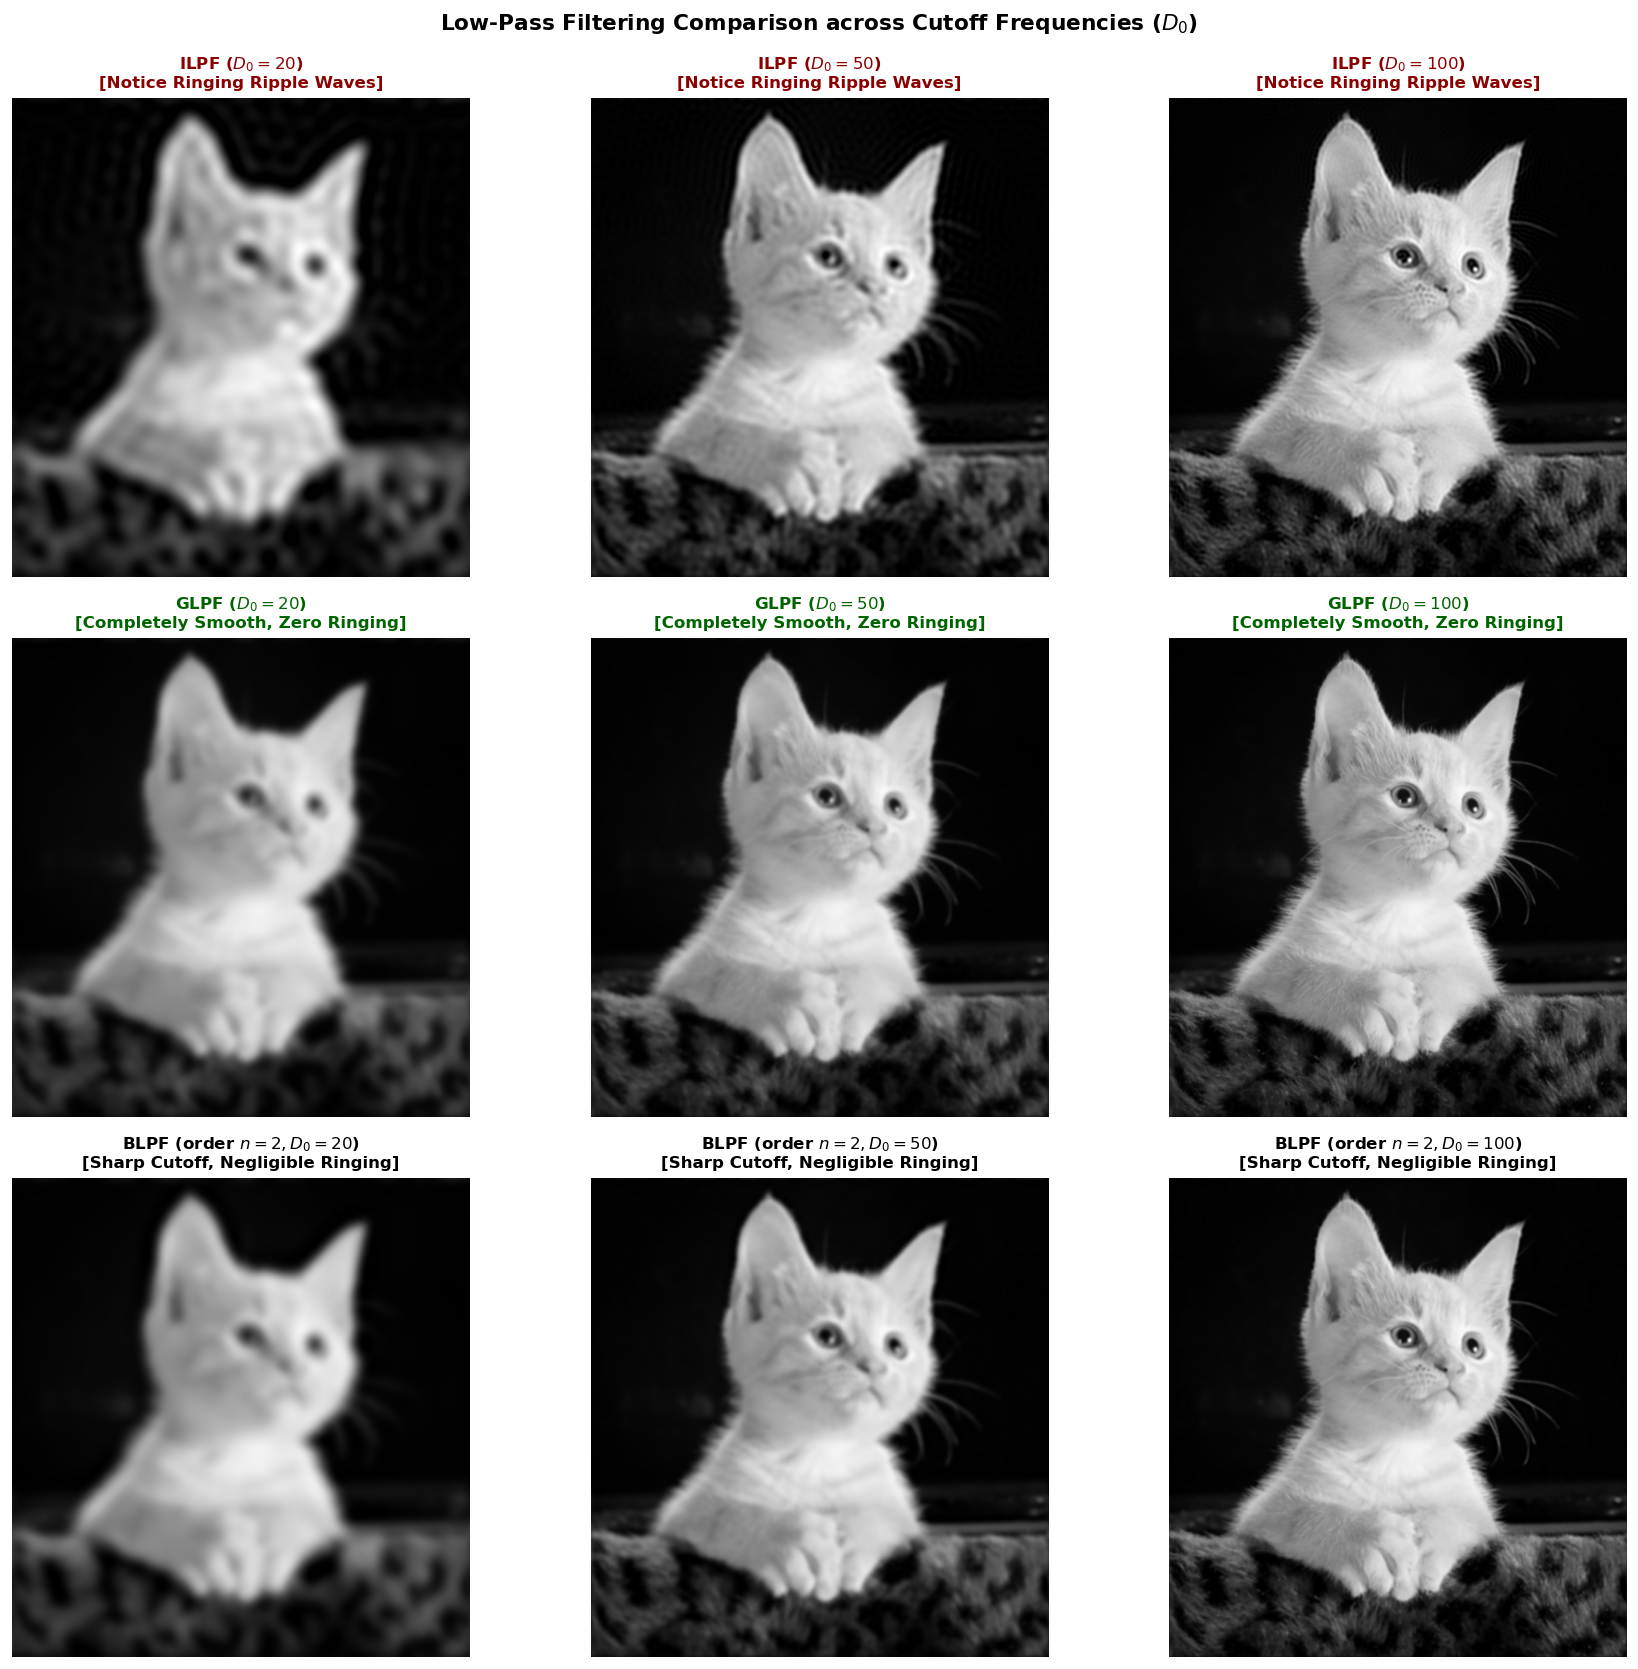

In [ ]:
cutoffs = [20.0, 50.0, 100.0]

fig, axes = plt.subplots(3, 3, figsize=(15, 14))

for col_idx, D0 in enumerate(cutoffs):
    # 1. Ideal Low-Pass Filter
    H_ilpf = create_ideal_filter((h, w), D0, filter_type="low")
    img_ilpf = apply_frequency_filter(f_shift, H_ilpf)

    # 2. Gaussian Low-Pass Filter
    H_glpf = create_gaussian_filter((h, w), D0, filter_type="low")
    img_glpf = apply_frequency_filter(f_shift, H_glpf)

    # 3. Butterworth Low-Pass Filter (order n=2)
    H_blpf = create_butterworth_filter((h, w), D0, n=2, filter_type="low")
    img_blpf = apply_frequency_filter(f_shift, H_blpf)

    # Row 1: ILPF
    axes[0, col_idx].imshow(img_ilpf, cmap="gray", vmin=0, vmax=255)
    axes[0, col_idx].set_title(
        f"ILPF ($D_0={int(D0)}$)\n[Notice Ringing Ripple Waves]",
        fontsize=10,
        fontweight="bold",
        color="darkred",
    )
    axes[0, col_idx].axis("off")

    # Row 2: GLPF
    axes[1, col_idx].imshow(img_glpf, cmap="gray", vmin=0, vmax=255)
    axes[1, col_idx].set_title(
        f"GLPF ($D_0={int(D0)}$)\n[Completely Smooth, Zero Ringing]",
        fontsize=10,
        fontweight="bold",
        color="darkgreen",
    )
    axes[1, col_idx].axis("off")

    # Row 3: BLPF (n=2)
    axes[2, col_idx].imshow(img_blpf, cmap="gray", vmin=0, vmax=255)
    axes[2, col_idx].set_title(
        f"BLPF (order $n=2, D_0={int(D0)}$)\n[Sharp Cutoff, Negligible Ringing]",
        fontsize=10,
        fontweight="bold",
    )
    axes[2, col_idx].axis("off")

plt.suptitle(
    "Low-Pass Filtering Comparison across Cutoff Frequencies ($D_0$)",
    fontsize=13,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout()
plt.show()

## (iv) High-Pass Filtering: Ideal vs. Gaussian vs. Butterworth (Edge Sharpening)


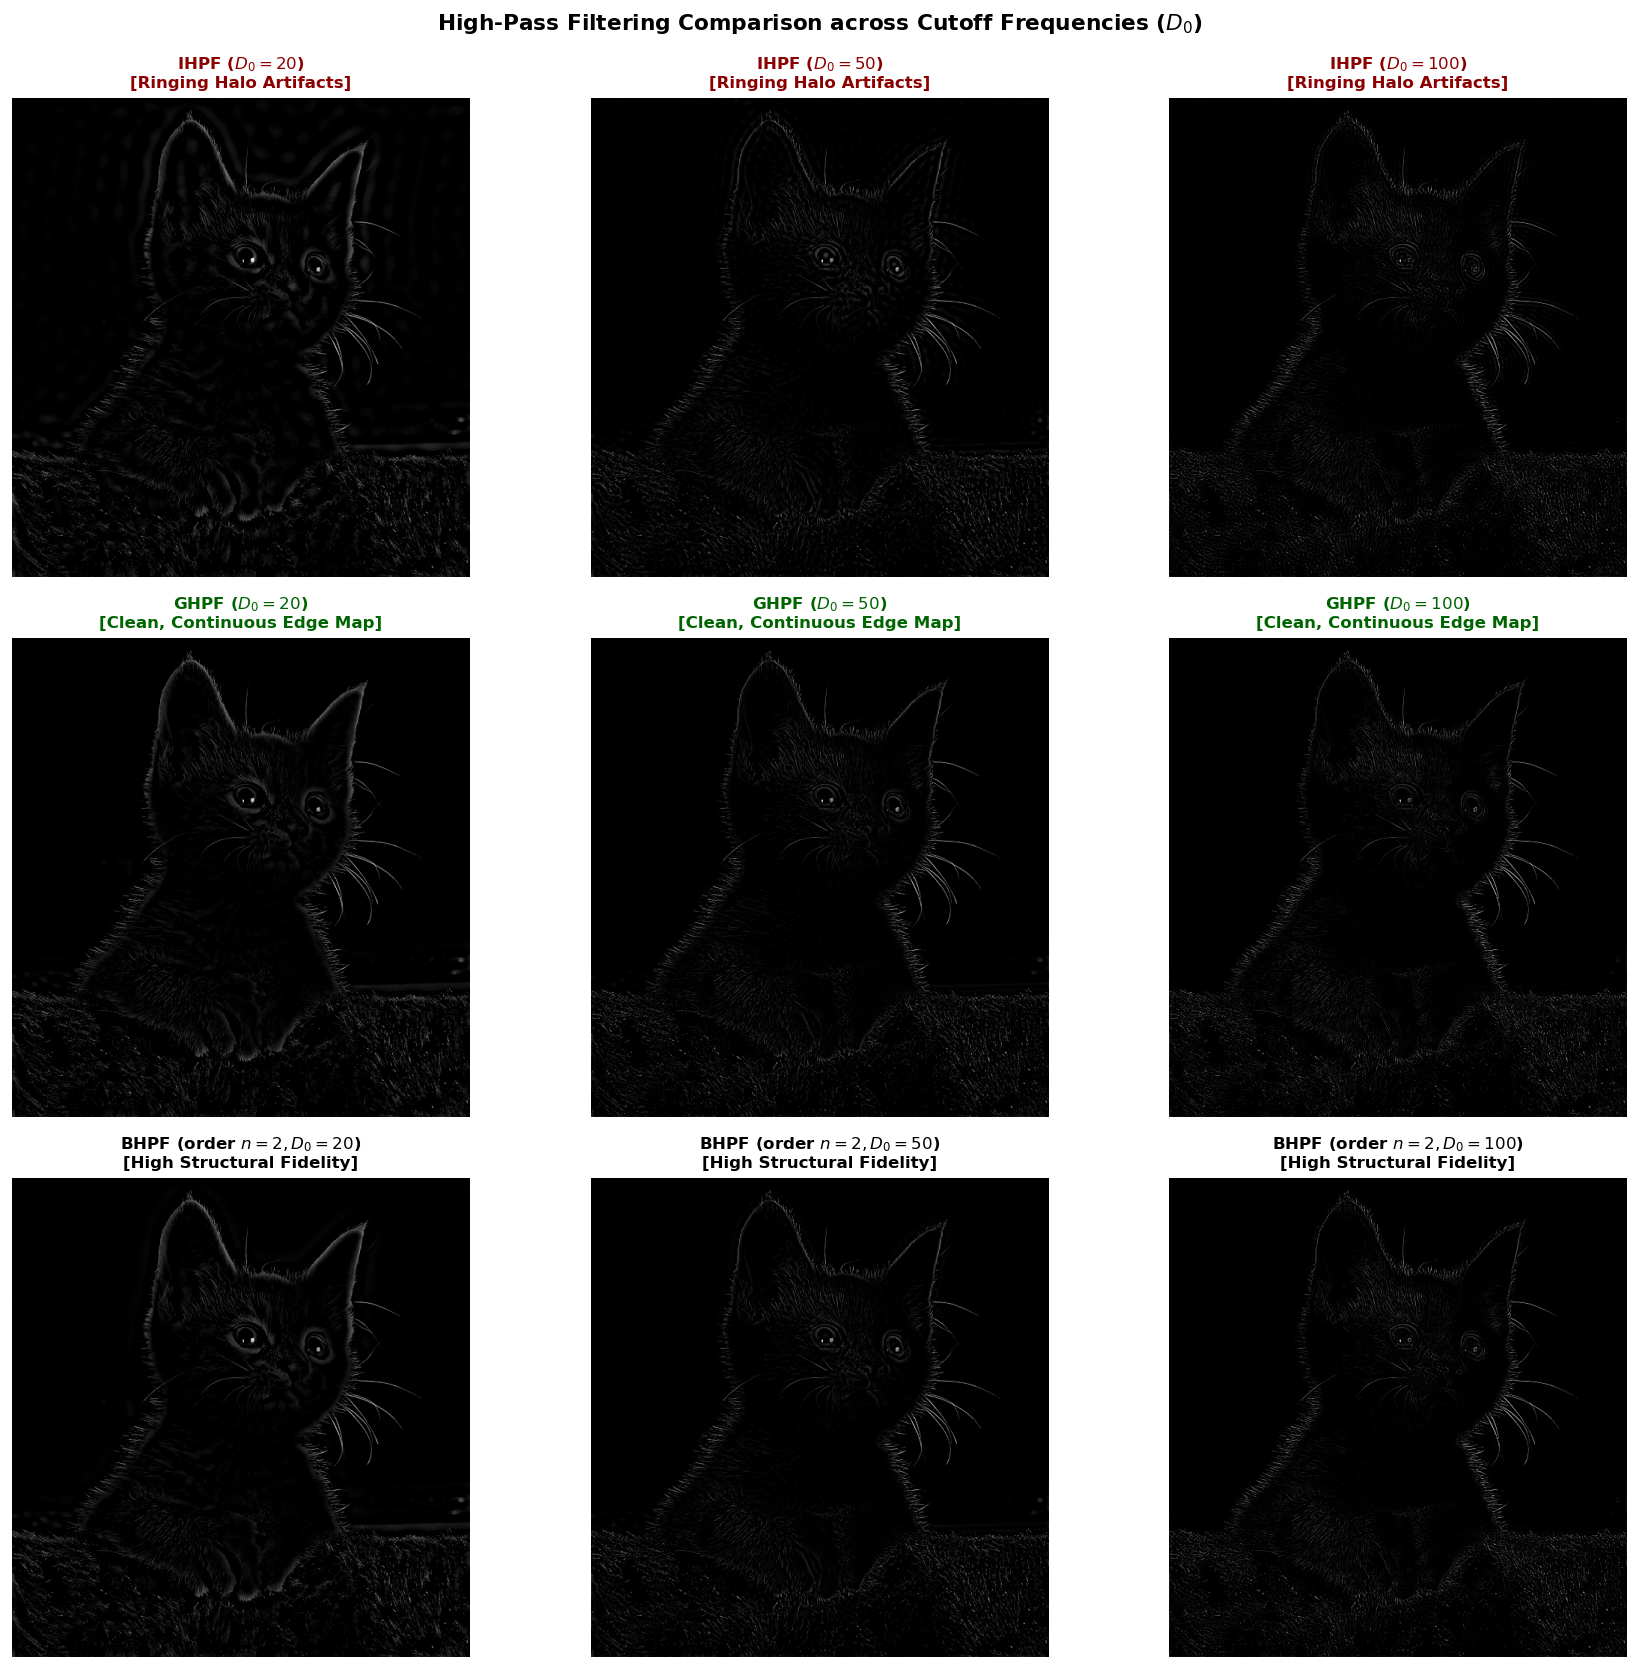

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14))

for col_idx, D0 in enumerate(cutoffs):
    # 1. Ideal High-Pass Filter
    H_ihpf = create_ideal_filter((h, w), D0, filter_type="high")
    img_ihpf = apply_frequency_filter(f_shift, H_ihpf)

    # 2. Gaussian High-Pass Filter
    H_ghpf = create_gaussian_filter((h, w), D0, filter_type="high")
    img_ghpf = apply_frequency_filter(f_shift, H_ghpf)

    # 3. Butterworth High-Pass Filter (order n=2)
    H_bhpf = create_butterworth_filter((h, w), D0, n=2, filter_type="high")
    img_bhpf = apply_frequency_filter(f_shift, H_bhpf)

    # Row 1: IHPF
    axes[0, col_idx].imshow(img_ihpf, cmap="gray")
    axes[0, col_idx].set_title(
        f"IHPF ($D_0={int(D0)}$)\n[Ringing Halo Artifacts]",
        fontsize=10,
        fontweight="bold",
        color="darkred",
    )
    axes[0, col_idx].axis("off")

    # Row 2: GHPF
    axes[1, col_idx].imshow(img_ghpf, cmap="gray")
    axes[1, col_idx].set_title(
        f"GHPF ($D_0={int(D0)}$)\n[Clean, Continuous Edge Map]",
        fontsize=10,
        fontweight="bold",
        color="darkgreen",
    )
    axes[1, col_idx].axis("off")

    # Row 3: BHPF (n=2)
    axes[2, col_idx].imshow(img_bhpf, cmap="gray")
    axes[2, col_idx].set_title(
        f"BHPF (order $n=2, D_0={int(D0)}$)\n[High Structural Fidelity]",
        fontsize=10,
        fontweight="bold",
    )
    axes[2, col_idx].axis("off")

plt.suptitle(
    "High-Pass Filtering Comparison across Cutoff Frequencies ($D_0$)",
    fontsize=13,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout()
plt.show()

## (v) Butterworth Filter Order Analysis: Effect of Parameter $n$ on Ringing & Roll-off


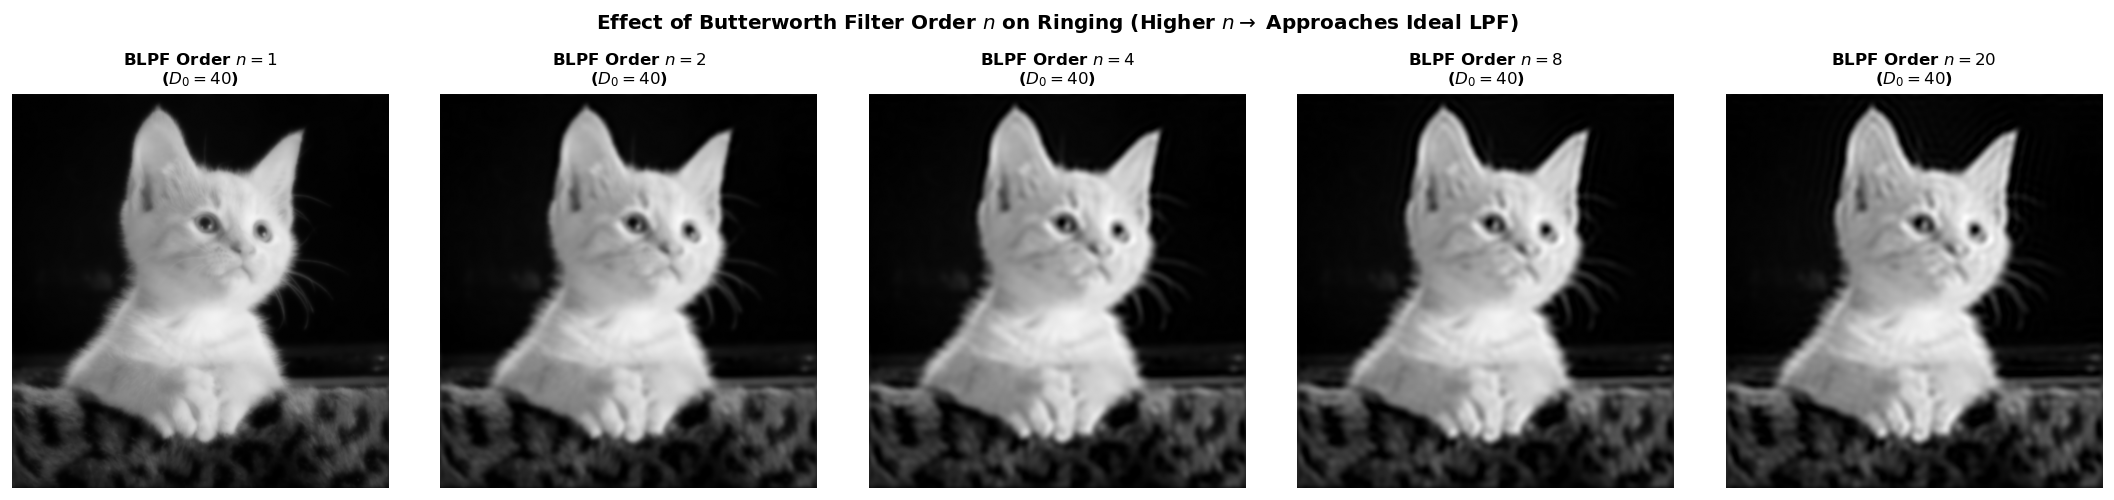

In [ ]:
orders = [1, 2, 4, 8, 20]
D0_fixed = 40.0

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, n in enumerate(orders):
    H_blpf_order = create_butterworth_filter(
        (h, w), D0=D0_fixed, n=n, filter_type="low"
    )
    img_blpf_order = apply_frequency_filter(f_shift, H_blpf_order)

    axes[idx].imshow(img_blpf_order, cmap="gray", vmin=0, vmax=255)
    axes[idx].set_title(
        f"BLPF Order $n={n}$\n($D_0=40$)", fontsize=10, fontweight="bold"
    )
    axes[idx].axis("off")

plt.suptitle(
    "Effect of Butterworth Filter Order $n$ on Ringing (Higher $n \\to$ Approaches Ideal LPF)",
    fontsize=12,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()

## (vi) Multi-Image Validation: Frequency Domain Filtering on Second Image (`image2.jpg`)


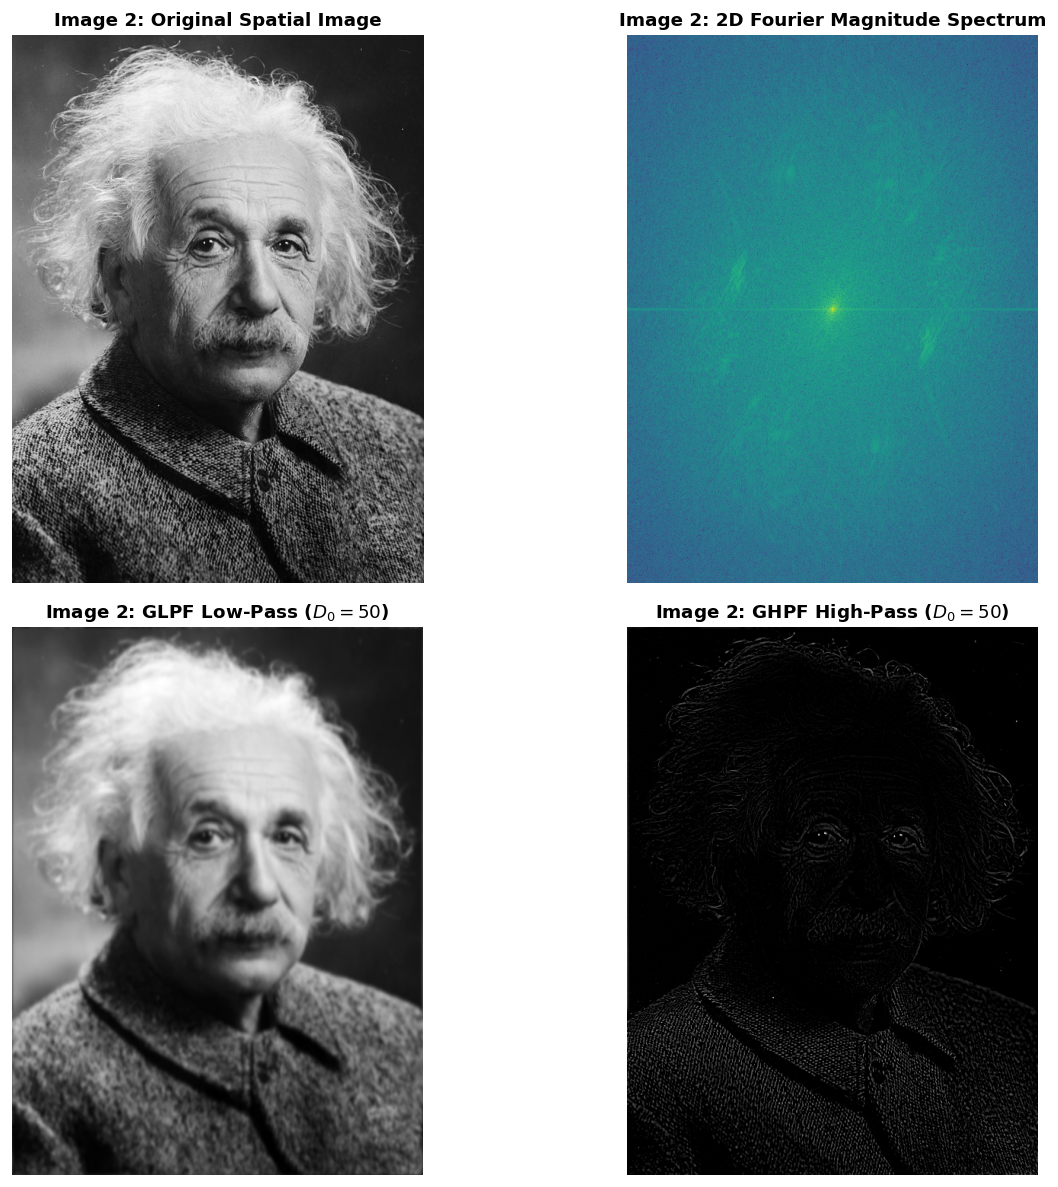

Image 2 frequency domain filtering completed successfully.


In [ ]:
# Load second test image
img2_clean = load_grayscale_image("images/image2.jpg")
h2, w2 = img2_clean.shape
_, f2_shift, mag2_spec = compute_2d_fft(img2_clean)

# Apply filters to Image 2
H2_glpf = create_gaussian_filter((h2, w2), D0=50.0, filter_type="low")
H2_ghpf = create_gaussian_filter((h2, w2), D0=50.0, filter_type="high")
H2_blpf = create_butterworth_filter((h2, w2), D0=50.0, n=2, filter_type="low")

img2_glpf = apply_frequency_filter(f2_shift, H2_glpf)
img2_ghpf = apply_frequency_filter(f2_shift, H2_ghpf)
img2_blpf = apply_frequency_filter(f2_shift, H2_blpf)

# Display Image 2 Results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img2_clean, cmap="gray")
axes[0, 0].set_title("Image 2: Original Spatial Image", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(mag2_spec, cmap="viridis")
axes[0, 1].set_title(
    "Image 2: 2D Fourier Magnitude Spectrum", fontsize=11, fontweight="bold"
)
axes[0, 1].axis("off")

axes[1, 0].imshow(img2_glpf, cmap="gray")
axes[1, 0].set_title(
    "Image 2: GLPF Low-Pass ($D_0=50$)", fontsize=11, fontweight="bold"
)
axes[1, 0].axis("off")

axes[1, 1].imshow(img2_ghpf, cmap="gray")
axes[1, 1].set_title(
    "Image 2: GHPF High-Pass ($D_0=50$)", fontsize=11, fontweight="bold"
)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print("Image 2 frequency domain filtering completed successfully.")

## (vii) Analytical Discussion & Comprehensive Theoretical Synthesis

### 1. Low-Pass vs. High-Pass Filtering Mechanisms

- **Low-Pass Filtering (Smoothing / Energy Compaction):**
  The vast majority of an image's structural energy ($>95\%$) is concentrated in the low-frequency DC neighborhood (representing smooth homogeneous regions and gradual illumination gradients). Low-pass filtering eliminates high-frequency components, effectively removing fine grain noise while blurring sharp edges.
- **High-Pass Filtering (Edge Sharpening & Feature Isolation):**
  High-pass filtering suppresses the low-frequency DC component and retains high-frequency spatial transitions. The resulting image isolates object boundaries, fine textures, and sharp transients on a dark zero-mean background.

---

### 2. Comprehensive Comparison: Ideal vs. Gaussian vs. Butterworth Filters

| Filter Family          | Transfer Function $H(u, v)$             | Transition Band Profile              | Gibbs Ringing Phenomenon                                                          | Optimal Use Case                                                                           |
| :--------------------- | :-------------------------------------- | :----------------------------------- | :-------------------------------------------------------------------------------- | :----------------------------------------------------------------------------------------- |
| **Ideal Filter**       | Hard step function at $D_0$             | Infinite slope (discontinuous jump)  | **Severe concentric ripple waves** caused by spatial $\text{sinc}$ oscillation.   | Theoretical benchmark; unsuitable for visual photography.                                  |
| **Gaussian Filter**    | Smooth exponential bell curve           | Gradual, continuous roll-off         | **Strictly zero ringing** (Fourier transform of Gaussian is Gaussian).            | Medical, astronomical, and scientific imaging where ringing artifacts cannot be tolerated. |
| **Butterworth Filter** | Smooth rational function with order $n$ | Controllable sharpness via order $n$ | **Zero ringing for $n=1$; negligible for $n=2$**; approaches Ideal for $n \ge 8$. | Industrial standard offering tunable balance between sharp cutoff and ringing suppression. |

---

### 3. Frequency Domain vs. Spatial Domain Filtering

- **Convolution Theorem Equivalence:**
  Spatial convolution with a $(2k+1) \times (2k+1)$ filter kernel is mathematically equivalent to pointwise multiplication in the Fourier domain:
  $$f(x, y) * h(x, y) \iff F(u, v) \cdot H(u, v)$$
- **Computational Complexity Trade-Off:**
  - **Spatial Domain:** $O(k^2 \cdot M N)$ operations per image. Highly efficient for small kernels ($3 \times 3, 5 \times 5$).
  - **Frequency Domain (via 2D FFT):** $O(M N \log(M N))$ operations independent of filter size. For large kernels ($k > 15$) or arbitrary complex transfer functions, frequency domain filtering is significantly faster.

---

### 4. Real-World Applications of Frequency Domain Processing

1. **Periodic Noise Removal (Notch Filtering):**
   Interference stripes or electronic hum appear as sharp discrete impulses (spikes) in the Fourier magnitude spectrum. Notch reject filters zero out these specific frequency coordinates without degrading overall spatial structure.
2. **Homomorphic Filtering (Illumination Correction):**
   Using the image formation model $I(x, y) = i(x, y) \cdot r(x, y)$ (illumination $\times$ reflectance), taking the natural logarithm separates them into an additive sum: $\ln I = \ln i + \ln r$. High-pass filtering in frequency space attenuates low-frequency non-uniform illumination while boosting high-frequency object reflectance.
3. **Medical Tomography (CT/MRI Reconstruction):**
   The **Projection-Slice Theorem** uses 1D Fourier transforms of X-ray projection angles to reconstruct full 2D cross-sectional slices of anatomical structures.
